In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
from wordcloud import WordCloud
from typing import Any, Dict, List

In [223]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to /home/cr/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/cr/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/cr/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [224]:
df = pd.read_csv("Fragebogen git-Lernspiel.csv")
df

,Zeitstempel,Welche Sprache sprichst du?\nWhat language do you speak?\n[1.1.N],Wie bist du auf diesen Fragebogen gestoßen? [2.1.N],In welchem Studiengang studierst du? [2.2.N],Wie alt bist du? [2.3.R],Mit welchem Geschlecht identifizierst du dich? [2.4.N],Welche Vorerfahrung hast du mit git? [2.5.N],Selbsteinschätzung [3.1.L] [ein Repository erstellen und erste commits durchführen.],"Selbsteinschätzung [3.1.L] [Branches erstellen, wechseln und zusammenführen (merge).]",Selbsteinschätzung [3.1.L] [Merge-Konflikte erkennen und lösen.],...,"Resource management: Effort [6.13.L] [When exercises become frustrating, I don't give up.]","Resource management: Effort [6.13.L] [I work hard to learn a subject, even if it doesn't appeal to me.]",Resource management: Peer learning [6.14.L] [I work with other students to learn.],Resource management: Peer learning [6.14.L] [I discuss problems with fellow students.],Resource management: Peer learning [6.14.L] [I try to explain concepts to others in order to understand them better.],Resource management: Seeking help [6.15.L] [I ask lecturers or tutors when I don't understand something.],Resource management: Seeking help [6.15.L] [I actively seek help when I get stuck.],Resource management: Seeking help [6.15.L] [I identify people who can help me with problems.],Would you like to participate in a later test of the git learning game? [7.1.B],Which email address should we use to contact you? [8.1.A]
0,2026/01/12 5:44:44 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Master Computer Science,23.0,Divers,Regelmäßig im Einsatz (z. B. in Projekten oder...,7 = trifft voll zu,7 = trifft voll zu,7 = trifft voll zu,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026/01/20 6:36:37 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,19.0,Männlich,Regelmäßig im Einsatz (z. B. in Projekten oder...,3,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026/01/20 6:37:45 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,17.0,Männlich,Regelmäßig im Einsatz (z. B. in Projekten oder...,7 = trifft voll zu,7 = trifft voll zu,7 = trifft voll zu,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026/01/20 6:38:25 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,21.0,Männlich,Grundkenntnisse (ein paar Befehle bekannt),7 = trifft voll zu,5,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026/01/20 6:38:37 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,19.0,Weiblich,Grundkenntnisse (ein paar Befehle bekannt),7 = trifft voll zu,3,1 = trifft gar nicht zu,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2026/01/20 6:39:37 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,19.0,Weiblich,Grundkenntnisse (ein paar Befehle bekannt),7 = trifft voll zu,5,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2026/01/20 6:41:08 PM MEZ,English,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,arvid.schmohl@gmail.com
7,2026/01/20 6:41:20 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,19.0,Männlich,Grundkenntnisse (ein paar Befehle bekannt),7 = trifft voll zu,6,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2026/01/20 6:41:29 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,18.0,Männlich,Regelmäßig im Einsatz (z. B. in Projekten oder...,7 = trifft voll zu,6,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2026/01/20 6:55:48 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,19.0,Weiblich,Grundkenntnisse (ein paar Befehle bekannt),5,4,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Create a cleaned dataframe that unifies German/English columns,
# renames columns to their ids, and extracts question texts.
import re
# read raw csv (again to ensure we use original headers)
df_raw = pd.read_csv("Fragebogen git-Lernspiel.csv")

def extract_id(col: str):
    m = re.search(r'\[([0-9]+\.[0-9]+\.[A-Za-z0-9]+)\]', col)
    return m.group(1) if m else None

# collect columns grouped by id
id_to_cols = {}
for c in df_raw.columns:
    _id = extract_id(c)
    if _id:
        id_to_cols.setdefault(_id, []).append(c)

# remove all id groups that start with '6' (exclude these columns)
id_to_cols = {k: v for k, v in id_to_cols.items() if not k.startswith('6')}

# helper to treat common explicit 'no answer' strings as missing
def is_missing(v):
    if pd.isna(v):
        return True
    s = str(v).strip()
    if s == '':
        return True
    low = s.lower()
    if low in ('keine angabe/kein antwort', 'keine angabe', 'no answer', 'no answer/kein answer', 'no answer/no answer'):
        return True
    return False

# output containers
cleaned = pd.DataFrame(index=df_raw.index)
id_to_de = {}
id_to_en = {}

# keep Zeitstempel column as-is if present
if 'Zeitstempel' in df_raw.columns:
    cleaned['Zeitstempel'] = df_raw['Zeitstempel']

# helper to extract label without the [id] part
def label_without_id(col: str, _id):
    # return re.sub(r'\s*\[' + re.escape(_id) + r'\].*$', '', col).strip()
    start, end = col.find("["), col.find("]")

    if start == -1:
        return col

    if col.count("[") > 1:
        start = col.find("[", end)
        end = col.find("]", start)
        return col[start + 1: end]

    else:
        return col[:start]

# convert Likert-like strings to numbers
def likert_to_number(v):
    if pd.isna(v):
        return 'X'
    s = str(v)
    m = re.search(r'(\d+)', s)
    if m:
        return int(m.group(1))
    return 'X'

# convert boolean-like answers to 1/0
def boolean_to_binary(v):
    if pd.isna(v):
        return 'X'
    s = str(v).strip().lower()
    if s in ('ja','yes','y','true','1','ok'):
        return 1
    if s in ('nein','no','n','false','0') :
        return 0
    # some answers may be empty or other text -> X
    return 'X'

# normalization helper to compare text values
def normalize_text(s):
    if pd.isna(s):
        return ''
    s = str(s).lower()
    s = re.sub(r'[^a-z0-9äöüß ]+', '', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

# Process each id-group: unify values and record German/English question text
for _id, cols in id_to_cols.items():
    typ = _id.split('.')[-1]
    # prepare labels for all columns in this group
    labels = [label_without_id(c, _id) for c in cols]
    # If Likert-like or Boolean and multiple columns exist, create sub-ids for each question item
    if typ in ('L', 'R', 'B') and len(cols) > 1:
        n = len(cols)
        # Heuristic: if even number of columns, assume first half German, second half English (pairwise)
        if n % 2 == 0:
            half = n // 2
            german_cols = cols[:half]
            english_cols = cols[half:half+half]
            for i, gcol in enumerate(german_cols):
                ecol = english_cols[i] if i < len(english_cols) else gcol
                sub_id = f"{_id}.{i+1}"
                g_label = label_without_id(gcol, _id)
                e_label = label_without_id(ecol, _id)
                id_to_de[sub_id] = g_label
                id_to_en[sub_id] = e_label
                tmp = df_raw[[gcol, ecol]].apply(lambda col: col.map(lambda v: np.nan if is_missing(v) else v))
                merged = tmp.apply(lambda row: next((x for x in row if pd.notna(x)), np.nan), axis=1)
                # choose mapper depending on type
                if typ in ('L','R'):
                    cleaned[sub_id] = merged.map(likert_to_number)
                else:
                    cleaned[sub_id] = merged.map(boolean_to_binary)
        else:
            # odd count: fall back to treating each column as its own sub-item (no pairing)
            for i, col in enumerate(cols):
                sub_id = f"{_id}.{i+1}"
                lab = labels[i]
                id_to_de[sub_id] = lab
                id_to_en[sub_id] = lab
                series = df_raw[col].map(lambda v: np.nan if is_missing(v) else v)
                if typ in ('L','R'):
                    cleaned[sub_id] = series.map(likert_to_number)
                else:
                    cleaned[sub_id] = series.map(boolean_to_binary)
    else:
        # Non-Likert or single-column: unify German/English into one column as before
        if len(cols) == 1:
            col = cols[0]
            label_no_id = label_without_id(col, _id)
            parts = [p.strip() for p in label_no_id.splitlines() if p.strip()]
            if len(parts) >= 2:
                german = parts[0]
                english = parts[1]
            else:
                german = label_no_id
                english = label_no_id
            id_to_de[_id] = german
            id_to_en[_id] = english
            series = df_raw[col].map(lambda v: np.nan if is_missing(v) else v)
            # nominal/text responses: keep text, mark missing as 'X'
            if typ == 'B':
                cleaned[_id] = series.map(boolean_to_binary)
            else:
                cleaned[_id] = series.map(lambda v: 'X' if pd.isna(v) else v)
        else:
            # multiple columns but not Likert: pick first non-missing across columns
            # If nominal and even count, build local translation maps but DO NOT store them globally
            if len(cols) % 2 == 0 and typ == 'N':
                half = len(cols) // 2
                german_cols = cols[:half]
                english_cols = cols[half:half+half]
                # build translation maps from observed pairs where both present (local only)
                g2e = {}
                e2g = {}
                for gcol, ecol in zip(german_cols, english_cols):
                    gseries = df_raw[gcol].map(lambda v: np.nan if is_missing(v) else v)
                    eseries = df_raw[ecol].map(lambda v: np.nan if is_missing(v) else v)
                    for gv, ev in zip(gseries, eseries):
                        if pd.notna(gv) and pd.notna(ev):
                            gs = str(gv).strip()
                            es = str(ev).strip()
                            if gs and es:
                                g2e.setdefault(gs, es)
                                e2g.setdefault(es, gs)
                # merge by taking first non-missing across all cols (keep original language present)
                tmp = df_raw[cols].apply(lambda col: col.map(lambda v: np.nan if is_missing(v) else v))
                merged = tmp.apply(lambda row: next((x for x in row if pd.notna(x)), np.nan), axis=1)
                cleaned[_id] = merged.map(lambda v: 'X' if pd.isna(v) else v)
                id_to_de[_id] = label_without_id(cols[0], _id)
                id_to_en[_id] = label_without_id(cols[half], _id)
            else:
                # fallback: no reliable pairing -> take first non-missing across group and keep as text
                tmp = df_raw[cols].apply(lambda col: col.map(lambda v: np.nan if is_missing(v) else v))
                merged = tmp.apply(lambda row: next((x for x in row if pd.notna(x)), np.nan), axis=1)
                id_to_de[_id] = label_without_id(cols[0], _id)
                id_to_en[_id] = label_without_id(cols[0], _id)
                cleaned[_id] = merged.map(lambda v: 'X' if pd.isna(v) else v)

# Final cleaned dataframe
cleaned_df = cleaned

# mappings: id -> German question, id -> English question
id_to_de, id_to_en

# preview
cleaned_df.head()

,Zeitstempel,1.1.N,2.1.N,2.2.N,2.3.R.1,2.4.N,2.5.N,3.1.L.1,3.1.L.2,3.1.L.3,...,4.2.L.4,4.2.L.5,5.1.T,5.2.T,5.3.T,5.4.T,5.5.N,5.6.T,7.1.B.1,8.1.A
0,2026/01/12 5:44:44 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Master Computer Science,23,Divers,Regelmäßig im Einsatz (z. B. in Projekten oder...,7,7,7,...,1,1,Am Anfang (zu Schulzeiten) sollte ich es für e...,ich merke mir halt wenig auswendig was ich jed...,X,Streaks/Ranking,Weniger als 30 Minuten,X,0,X
1,2026/01/20 6:36:37 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,19,Männlich,Regelmäßig im Einsatz (z. B. in Projekten oder...,3,3,3,...,2,X,X,X,Merge inkl. Konflikte,X,30 - 60 Minuten,X,0,X
2,2026/01/20 6:37:45 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,17,Männlich,Regelmäßig im Einsatz (z. B. in Projekten oder...,7,7,7,...,3,2,X,X,basics,X,Weniger als 30 Minuten,X,0,X
3,2026/01/20 6:38:25 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,21,Männlich,Grundkenntnisse (ein paar Befehle bekannt),7,5,3,...,7,4,Der Anfang :/,"Keine; fühle mich wohl mit dem was ich mache, ...","Basics: add, Commit, push pull und branch merge",Story-Modus mit Leveln,30 - 60 Minuten,Coole Idee - bitte integrieren in Vorkurs,1,joshua.dashti@student.hpi.de
4,2026/01/20 6:38:37 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,19,Weiblich,Grundkenntnisse (ein paar Befehle bekannt),7,3,1,...,4,1,Bis jetzt noch wenig usecases,Branching/ Merging,Zusammenarbeit,"Story, Multiplayer",30 - 60 Minuten,X,0,X


In [ ]:
nominal_columns = [c for c in cleaned_df.columns if ".N" in c]
nominal_scale_answers: Dict[str, Dict[str, List[str]]] = {
    "1.1.N": {
        "de": [
            "Deutsch",
            "Englisch"
        ],
        "en": [
            "German",
            "English"
        ]
    },
    "2.1.N": {
        "de": [
            "Ich habe eine Email bekommen.",
            "In der Telegram-Gruppe.",
            "Ich fülle ihn im Rahmen des Stubs aus.",
            "Anderes"
        ],
        "en": [
            "I received an email.",
            "In the Telegram group.",
            "I fill it out in the Stubs.",
            "Other"
        ]
    },
    "2.2.N": {
        "de": [
            "Bachelor ITSE",
            "Master ITSE",
            "Master Computer Science",
            "Master Cyber Security",
            "Master Digital Health",
            "Master Data Engineering",
            "Anderer Bachelor",
            "Anderer Master",
            "Nichts davon",
            "Keine Angabe"
        ],
        "en": [
            "Bachelor ITSE",
            "Master ITSE",
            "Master Computer Science",
            "Master Cyber Security",
            "Master Digital Health",
            "Master Data Engineering",
            "Other Bachelor",
            "Other Master",
            "Nothing of the above",
            "No answer"
        ]
    },
    "2.4.N": {
        "de": [
            "Weiblich",
            "Männlich",
            "Divers",
            "Keine Angabe"
        ],
        "en": [
            "Female",
            "Male",
            "Diverse",
            "No answer"
        ]
    },
    "2.5.N": {
        "de": [
            "Keine",
            "Grundkenntnisse (ein paar Befehle bekannt)",
            "Regelmäßig im Einsatz (z. B. in Projekten oder Praktika)",
            "Fortgeschritten (täglicher Einsatz, komplexe Workflows)"
        ],
        "en": [
            "None",
            "Basic knowledge (familiar with a few commands)",
            "Regularly used (e.g., in projects or internships)",
            "Advanced (daily use, complex workflows)"
        ]
    },
    "5.5.N": {
        "de": [
            "Weniger als 30 Minuten",
            "30 - 60 Minuten",
            "1 - 2 Stunden",
            "Mehr als 2 Stunden"
        ],
        "en": [
            "less than 30 minutes",
            "30 - 60 minutes",
            "1 - 2 hours",
            "more than 2 hours"
        ]
    },
}

def translate_nominal_answers(value: Any, column: str) -> Any:
    if value in nominal_scale_answers[column]["de"]:
        return value

    elif value in nominal_scale_answers[column]["en"]:
        answer_index = nominal_scale_answers[column]["en"].index(value)
        return nominal_scale_answers[column]["de"][answer_index]

    else:
        raise ValueError()


cleaned_german_df = cleaned_df.copy()
for column in nominal_columns:
    cleaned_german_df[column] = cleaned_german_df[column].apply(lambda v: translate_nominal_answers(v, column))

cleaned_german_df.head()

,Zeitstempel,1.1.N,2.1.N,2.2.N,2.3.R.1,2.4.N,2.5.N,3.1.L.1,3.1.L.2,3.1.L.3,...,4.2.L.4,4.2.L.5,5.1.T,5.2.T,5.3.T,5.4.T,5.5.N,5.6.T,7.1.B.1,8.1.A
0,2026/01/12 5:44:44 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Master Computer Science,23,Divers,Regelmäßig im Einsatz (z. B. in Projekten oder...,7,7,7,...,1,1,Am Anfang (zu Schulzeiten) sollte ich es für e...,ich merke mir halt wenig auswendig was ich jed...,X,Streaks/Ranking,Weniger als 30 Minuten,X,0,X
1,2026/01/20 6:36:37 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,19,Männlich,Regelmäßig im Einsatz (z. B. in Projekten oder...,3,3,3,...,2,X,X,X,Merge inkl. Konflikte,X,30 - 60 Minuten,X,0,X
2,2026/01/20 6:37:45 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,17,Männlich,Regelmäßig im Einsatz (z. B. in Projekten oder...,7,7,7,...,3,2,X,X,basics,X,Weniger als 30 Minuten,X,0,X
3,2026/01/20 6:38:25 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,21,Männlich,Grundkenntnisse (ein paar Befehle bekannt),7,5,3,...,7,4,Der Anfang :/,"Keine; fühle mich wohl mit dem was ich mache, ...","Basics: add, Commit, push pull und branch merge",Story-Modus mit Leveln,30 - 60 Minuten,Coole Idee - bitte integrieren in Vorkurs,1,joshua.dashti@student.hpi.de
4,2026/01/20 6:38:37 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,19,Weiblich,Grundkenntnisse (ein paar Befehle bekannt),7,3,1,...,4,1,Bis jetzt noch wenig usecases,Branching/ Merging,Zusammenarbeit,"Story, Multiplayer",30 - 60 Minuten,X,0,X


In [ ]:
cleaned_german_df_only_bachelor = cleaned_german_df[cleaned_german_df["2.2.N"].str.contains("Bachelor")]

final_df = cleaned_german_df_only_bachelor
final_df

,Zeitstempel,1.1.N,2.1.N,2.2.N,2.3.R.1,2.4.N,2.5.N,3.1.L.1,3.1.L.2,3.1.L.3,...,4.2.L.4,4.2.L.5,5.1.T,5.2.T,5.3.T,5.4.T,5.5.N,5.6.T,7.1.B.1,8.1.A
1,2026/01/20 6:36:37 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,19,Männlich,Regelmäßig im Einsatz (z. B. in Projekten oder...,3,3,3,...,2,X,X,X,Merge inkl. Konflikte,X,30 - 60 Minuten,X,0,X
2,2026/01/20 6:37:45 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,17,Männlich,Regelmäßig im Einsatz (z. B. in Projekten oder...,7,7,7,...,3,2,X,X,basics,X,Weniger als 30 Minuten,X,0,X
3,2026/01/20 6:38:25 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,21,Männlich,Grundkenntnisse (ein paar Befehle bekannt),7,5,3,...,7,4,Der Anfang :/,"Keine; fühle mich wohl mit dem was ich mache, ...","Basics: add, Commit, push pull und branch merge",Story-Modus mit Leveln,30 - 60 Minuten,Coole Idee - bitte integrieren in Vorkurs,1,joshua.dashti@student.hpi.de
4,2026/01/20 6:38:37 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,19,Weiblich,Grundkenntnisse (ein paar Befehle bekannt),7,3,1,...,4,1,Bis jetzt noch wenig usecases,Branching/ Merging,Zusammenarbeit,"Story, Multiplayer",30 - 60 Minuten,X,0,X
5,2026/01/20 6:39:37 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,19,Weiblich,Grundkenntnisse (ein paar Befehle bekannt),7,5,3,...,3,4,X,X,X,"Story, Rangliste",Weniger als 30 Minuten,X,1,liv.brts@gmail.com
6,2026/01/20 6:41:08 PM MEZ,Englisch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,19,Männlich,Grundkenntnisse (ein paar Befehle bekannt),7,4,2,...,2,4,X,X,X,X,1 - 2 Stunden,X,1,arvid.schmohl@gmail.com
7,2026/01/20 6:41:20 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,19,Männlich,Grundkenntnisse (ein paar Befehle bekannt),7,6,4,...,4,7,Die offizielle Dokumentation von git ist nicht...,X,Das man nur einen SSH Server benötigt um zusam...,Rätsel und Multiplayer,1 - 2 Stunden,X,1,frederik.mercy@student.hpi.uni-potsdam.de
8,2026/01/20 6:41:29 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,18,Männlich,Regelmäßig im Einsatz (z. B. in Projekten oder...,7,6,4,...,4,6,branched managen/zurücksetzen/auseinanderhalten,rebasen,branch head managen,"Rätsel, Sandbox",1 - 2 Stunden,X,1,alexander.schicktanz@web.de
9,2026/01/20 6:55:48 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,19,Weiblich,Grundkenntnisse (ein paar Befehle bekannt),5,4,4,...,7,6,"Merge Conflikte ohne zu wissen, wie man diese ...",Merge,Erstellen eines keys und den key reseten,Multiplayer wäre super um zu lernen mit andere...,1 - 2 Stunden,X,1,judith.schramm@vodafone.de
10,2026/01/20 7:20:11 PM MEZ,Deutsch,Ich fülle ihn im Rahmen des Stubs aus.,Bachelor ITSE,20,Weiblich,Grundkenntnisse (ein paar Befehle bekannt),5,3,1,...,6,7,X,X,X,X,1 - 2 Stunden,X,1,stierla5@gmail.com


In [ ]:
def autopct_format(values):
    def my_format(pct):
        absolute = int(round(pct/100.*sum(values)))
        return f"{pct:.1f}%\n({absolute})"
    return my_format


def pie_plot(df: pd.DataFrame, qid: str):
    counts = df[qid].value_counts()
    plt.pie(
        x=counts,
        labels=list(df[qid].unique()),
        autopct=autopct_format(counts)
    )
    plt.title(id_to_de[qid])
    plt.savefig(f"figures/{qid}.png")
    plt.show()


def histogram_plot(df: pd.DataFrame, qid: str, xlabel: str):
    unique_ages = sorted(df[qid].unique())
    ages = list(range(min(unique_ages), max(unique_ages) + 1))

    bins = [age - 0.5 for age in ages] + [ages[-1] + 0.5]

    plt.figure(figsize=(10, 6))
    plt.hist(df[qid], bins=bins, rwidth=0.8)

    plt.xticks(ages)
    plt.xlabel(xlabel)
    plt.ylabel("Häufigkeit")
    plt.title(id_to_de[qid])

    plt.savefig(f"figures/{qid}.png")
    plt.show()


def likert_plot(df: pd.DataFrame, qid: str, sub_id_range: range, title: str):
    # Define the Likert scale options
    likert_scale = [1, 2, 3, 4, 5, 6, 7, "X"]

    # Initialize a list to store the frequency of each response for all questions
    heatmap_data = []

    # Iterate over each question (sub_id)
    for sub_id in sub_id_range:
        col_name = f"{qid}.{sub_id}"
        if col_name in df.columns:
            # Count the frequency of each response
            response_counts = df[col_name].value_counts().reindex(likert_scale, fill_value=0)
            heatmap_data.append(response_counts.values)

    # Convert to a numpy array for the heatmap
    heatmap_data = np.array(heatmap_data).T  # Transpose to have responses on the y-axis

    plt.figure(figsize=(12, 8))

    # Create the heatmap
    cax = plt.matshow(heatmap_data, cmap="plasma")

    # Add a colorbar
    plt.colorbar(cax, label="Häufigkeit")

    # Set x-axis and y-axis ticks and labels
    plt.xticks(
        ticks=range(len(sub_id_range)),
        labels=[f"{qid}.{sub_id}" for sub_id in sub_id_range],
        rotation=85,
        ha="right",
    )
    plt.yticks(ticks=range(len(likert_scale)), labels=likert_scale)

    # Annotate each cell with the frequency
    for i in range(heatmap_data.shape[0]):
        for j in range(heatmap_data.shape[1]):
            plt.text(
                j, i, str(int(heatmap_data[i, j])),
                ha="center", va="center", color="black"
            )

    # Add labels and title
    plt.xlabel("Frage")
    plt.ylabel("Likert Antwort")
    plt.title(title)

    # Show the plot
    plt.savefig(f"figures/{qid}.png")
    plt.show()

    for sub_id in sub_id_range:
        id_ = f"{qid}.{sub_id}"
        print(f"{id_}: {id_to_de[id_]}")


def wordcloud_plot(df: pd.DataFrame, qid: str):
    def preprocess_text(text):
        # Tokenize
        tokens = word_tokenize(text.lower())
        # Remove punctuation and stopwords
        tokens = [
            t for t in tokens
            if t not in stopwords.words("german")
            and t not in stopwords.words("english")
            and t not in string.punctuation
        ]
        # Lemmatize
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
        return " ".join(tokens)

    # Example data
    texts = [t for t in df[qid] if t != "X"]
    with open(f"texts/{qid}.txt", 'w') as file:
        file.writelines([f"{t}\n" for t in texts])

    # Preprocess all texts
    processed_texts = [preprocess_text(t) for t in texts]

    # Extract n-grams (e.g., bigrams)
    vectorizer = CountVectorizer(ngram_range=(1,1))  # Unigrams
    X = vectorizer.fit_transform(processed_texts)
    words = vectorizer.get_feature_names_out()
    frequencies = X.sum(axis=0).A1

    # Pair words with their frequencies
    word_freq = dict(zip(words, frequencies))

    wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")

    plt.savefig(f"figures/{qid}.png")
    plt.show()

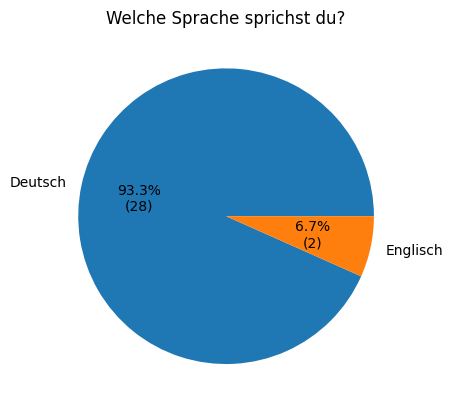

In [229]:
pie_plot(final_df, "1.1.N")

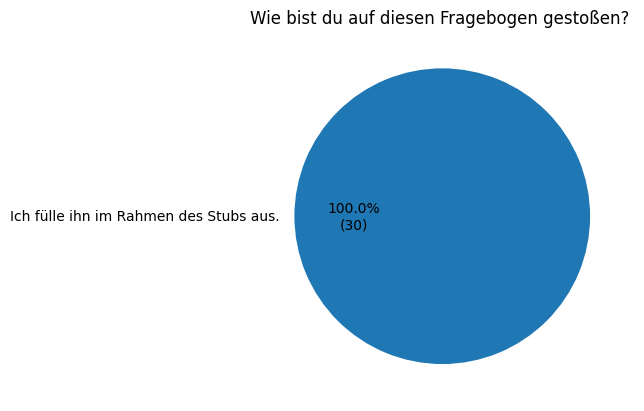

In [230]:
pie_plot(final_df, "2.1.N")

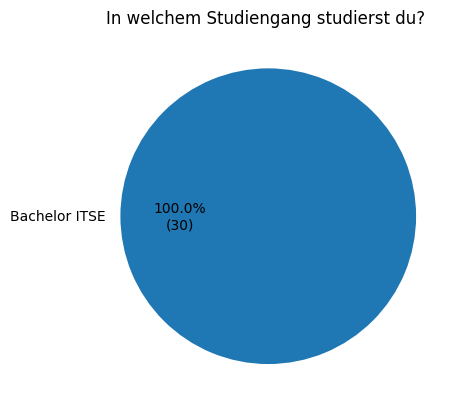

In [231]:
pie_plot(final_df, "2.2.N")

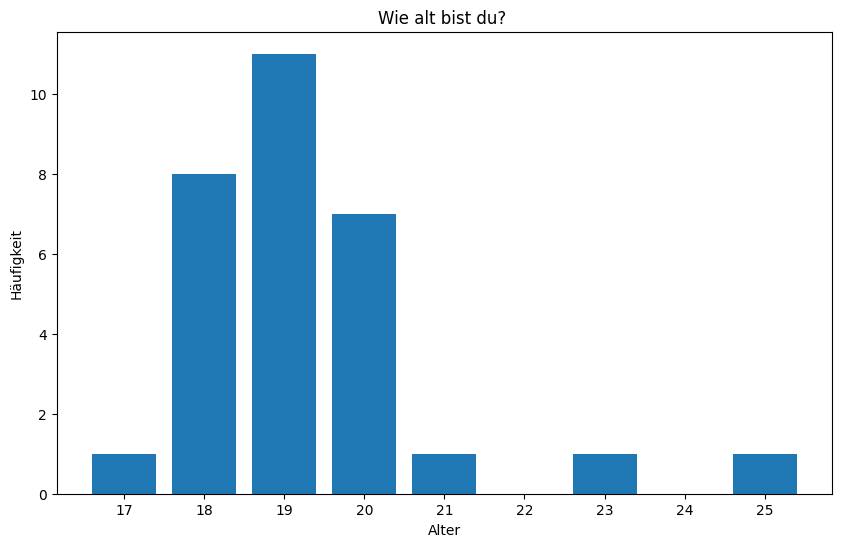

In [232]:
histogram_plot(final_df, "2.3.R.1", "Alter")

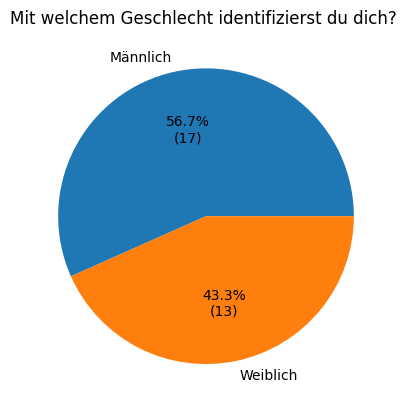

In [233]:
pie_plot(final_df, "2.4.N")

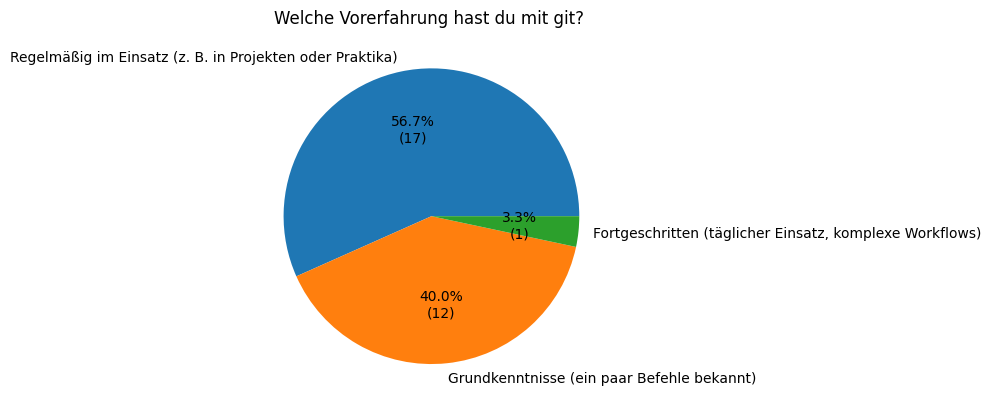

In [234]:
pie_plot(final_df, "2.5.N")

<Figure size 1200x800 with 0 Axes>

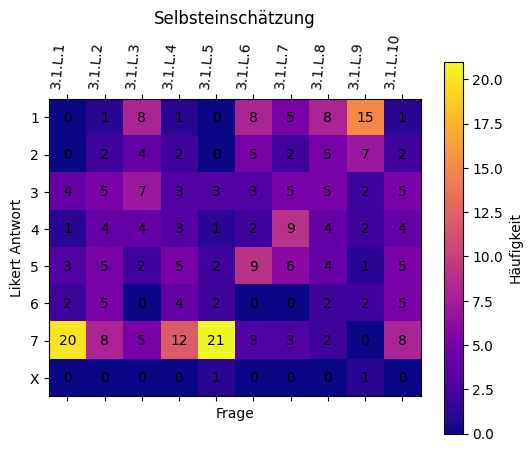

3.1.L.1: ein Repository erstellen und erste commits durchführen.
3.1.L.2: Branches erstellen, wechseln und zusammenführen (merge).
3.1.L.3: Merge-Konflikte erkennen und lösen.
3.1.L.4: den Unterschied zwischen lokalem und remote-Repository verstehen.
3.1.L.5: Änderungen pushen und pullen.
3.1.L.6: Rebase verwenden und von merge unterscheiden.
3.1.L.7: Commits rückgängig machen (revert, reset).
3.1.L.8: Einzelne commits gezielt übernehmen (cherrypick).
3.1.L.9: bisect zur Fehlersuche verwenden.
3.1.L.10: mit git in Teamprojekten arbeiten.


In [235]:
likert_plot(final_df, "3.1.L", range(1, 10 + 1), "Selbsteinschätzung")

<Figure size 1200x800 with 0 Axes>

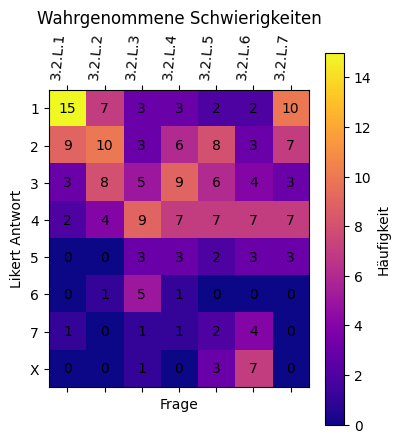

3.2.L.1: das Grundprinzip von commits und history zu verstehen.
3.2.L.2: Branching und merging anwenden.
3.2.L.3: merge-Konflikte zu beheben.
3.2.L.4: Änderungen rückgängig zu machen (revert, reset).
3.2.L.5: Einzelne commits zu übernehmen (cherrypick).
3.2.L.6: Fehlerquellen mit bisect zu finden.
3.2.L.7: über remote Repositories zusammen zu arbeiten.


In [236]:
likert_plot(final_df, "3.2.L", range(1, 7 + 1), "Wahrgenommene Schwierigkeiten")

<Figure size 1200x800 with 0 Axes>

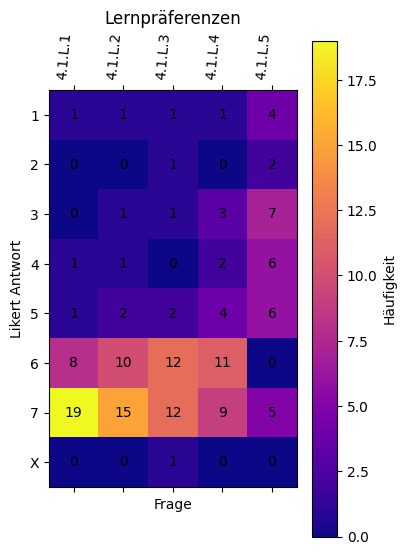

4.1.L.1: Ich lerne durch praktische Übungen.
4.1.L.2: Visuelle Darstellungen helfen mir beim Verstehen von Lerninhalten.
4.1.L.3: Ich lerne am besten durch Trial & Error und direktes Ausprobieren.
4.1.L.4: Schritt-für-Schritt-Anleitungen helfen mir beim Lernen
4.1.L.5: Ich lerne lieber allein als in der Gruppe.


In [237]:
likert_plot(final_df, "4.1.L", range(1, 5 + 1), "Lernpräferenzen")

<Figure size 1200x800 with 0 Axes>

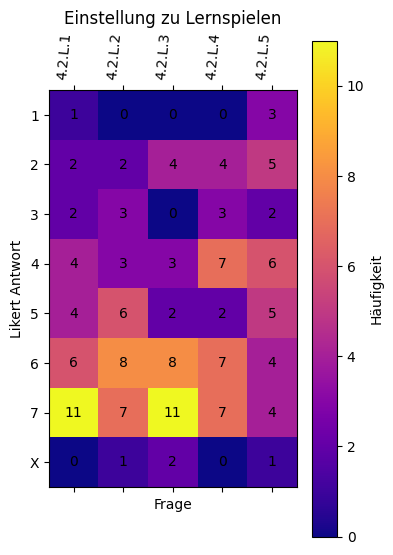

4.2.L.1: Ich hätte Spaß daran, git-Konzepte in einem Spiel zu üben.
4.2.L.2: Ein Lernspiel würde mir helfen, git-Abläufe besser zu verstehen.
4.2.L.3: Ich würde ein git-Lernspiel nutzen, wenn es in mein Studium integriert wäre.
4.2.L.4: Spielelemente (z. B. Punkte, Levels) würden mich motivieren, mehr zu üben.
4.2.L.5: Ich würde ein git-Lernspiel auch freiwillig außerhalb einer Veranstaltung nutzen.


In [238]:
likert_plot(final_df, "4.2.L", range(1, 5 + 1), "Einstellung zu Lernspielen")

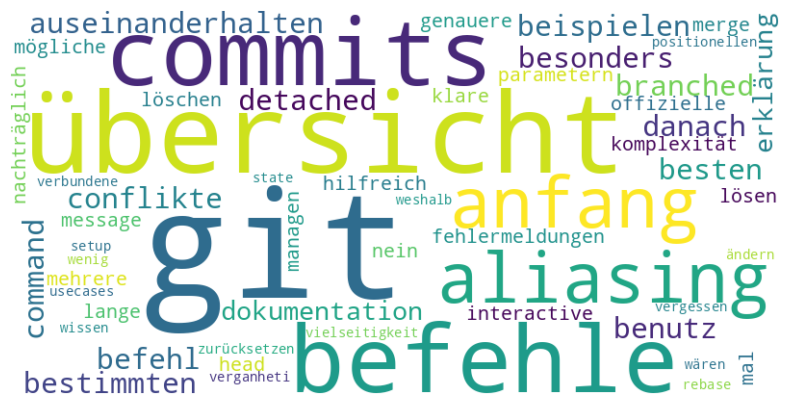

In [239]:
wordcloud_plot(final_df, "5.1.T")

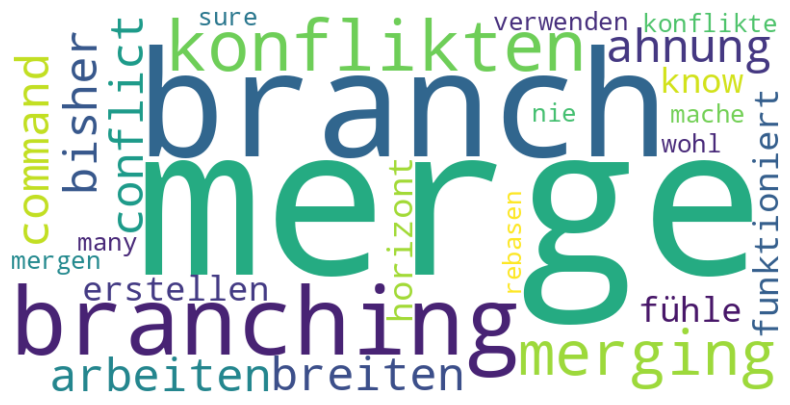

In [240]:
wordcloud_plot(final_df, "5.2.T")

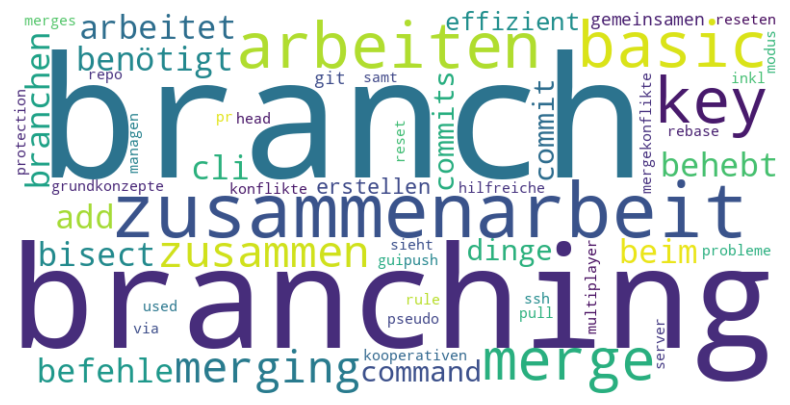

In [241]:
wordcloud_plot(final_df, "5.3.T")

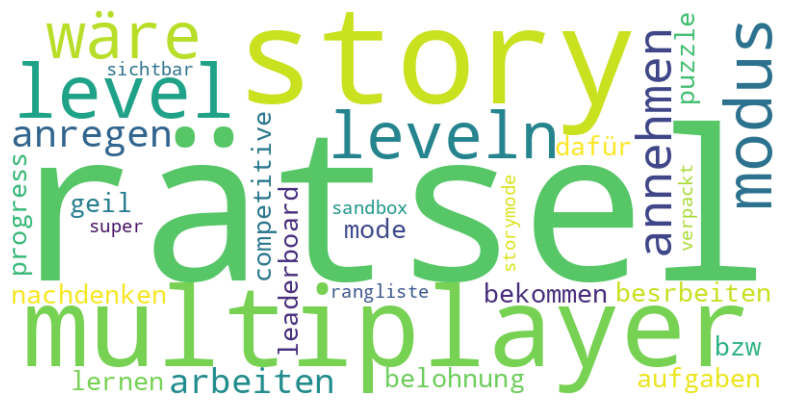

In [242]:
wordcloud_plot(final_df, "5.4.T")

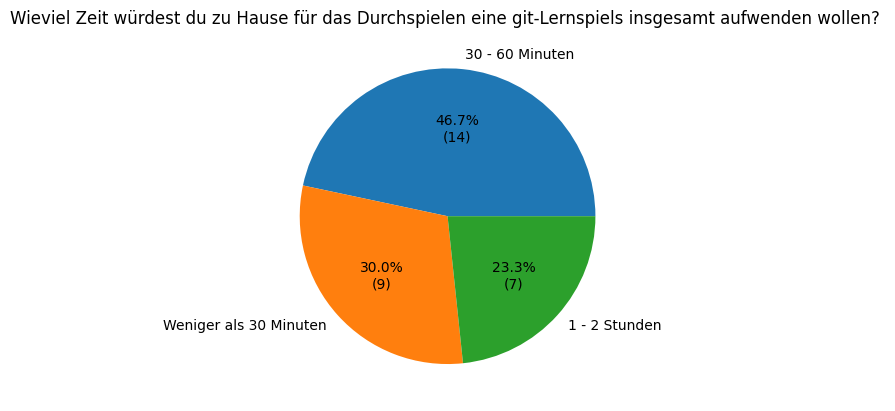

In [243]:
pie_plot(final_df, "5.5.N")

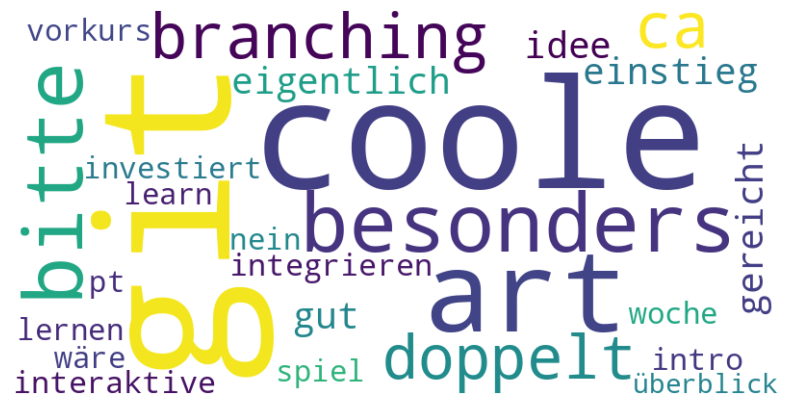

In [244]:
wordcloud_plot(final_df, "5.6.T")

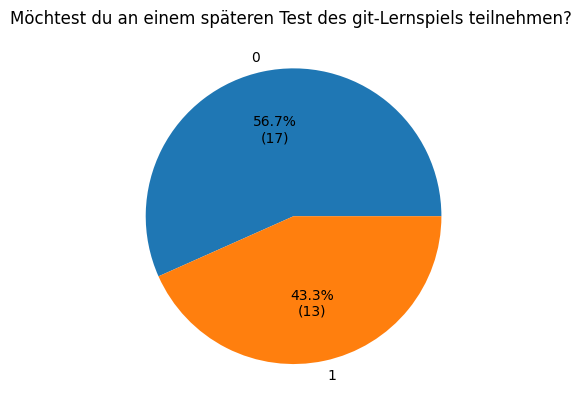

In [178]:
pie_plot(final_df, "7.1.B.1")